# Kv2.1 L403A: all-distance sampling breadth at equal depth

This notebook expands the S6-focused sampling analysis to every exact shared numerical distance in the established `all_ok_rmsd_3A_structural_interface_alignment_qc` vanilla and masked L403A tables: 705 Cα distances and 705 shortest-heavy-atom distances.

It asks whether masking broadens the complete precomputed distance ensemble, whether that effect is already visible in the first 1,000 retained structures, and how closely early results reproduce complete-QC results.

## Statistical design

Rows are ordered deterministically by seed, model number, and recycle; this is an indexed equal-depth analysis, not timestamped wall-clock chronology. Global IQR ratios describe the complete distributions. For inference, an IQR is calculated within each seed for every distance, making seed—not recycle snapshot—the statistical unit. Vanilla and masked seed-IQR distributions are compared with two-sided Mann–Whitney tests followed by Benjamini–Hochberg FDR correction within each sampling depth. Distributional separation is additionally summarized by Wasserstein distance between trajectory medians.

Positive log2 ratios mean broader masked sampling; negative values mean broader vanilla sampling. Breadth is not equivalent to accuracy or experimental relevance.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
from IPython.display import display, Image
repo_root=Path.cwd()
if not (repo_root/'shared').is_dir(): repo_root=repo_root.parent
sys.path.insert(0,str(repo_root))
from kv21.run_l403a_all_distance_sampling_analysis import run, TAB, FIG
result=run(); print(json.dumps(result['audit'],indent=2))

findfont: Failed to find font weight semibold, now using 700.


{
  "shared_distance_columns": 1410,
  "distance_types": {
    "CA": 705,
    "shortest_heavy": 705
  },
  "depths": [
    250,
    500,
    1000,
    2000,
    "Full QC"
  ],
  "ordering": "seed/model/recycle; deterministic, not timestamped chronology",
  "inference": "Mann-Whitney comparison of within-seed IQR; BH FDR within depth",
  "separation": "Wasserstein distance between trajectory medians"
}


## Ensemble-wide summary across sampling depths

,depth,distances,median_global_IQR_ratio,fraction_global_broader_masked,median_seed_IQR_ratio,fraction_seed_broader_masked,fraction_seed_breadth_q_lt_0.05,fraction_significant_broader_masked,fraction_significant_narrower_masked,median_trajectory_W1_A,median_normalized_W1,vanilla_rows,masked_rows,vanilla_seeds,masked_seeds
0,250,1410,1.951910,0.848936,1.943750,0.847518,0.256738,0.211348,0.045390,0.808631,0.594049,250,250,6,8
1,500,1410,1.427918,0.795745,2.016718,0.863830,0.592908,0.536170,0.056738,0.760230,0.604007,500,500,12,14
2,1000,1410,1.750000,0.823404,2.250000,0.851773,0.858865,0.773050,0.084397,0.722416,0.603744,1000,1000,23,28
3,2000,1410,2.131884,0.836170,2.122677,0.845390,0.912057,0.804965,0.103546,0.702064,0.588247,2000,2000,46,56
4,Full QC,1410,2.147603,0.829787,2.124188,0.840426,0.943972,0.819858,0.119858,0.712142,0.574638,4371,3693,100,100


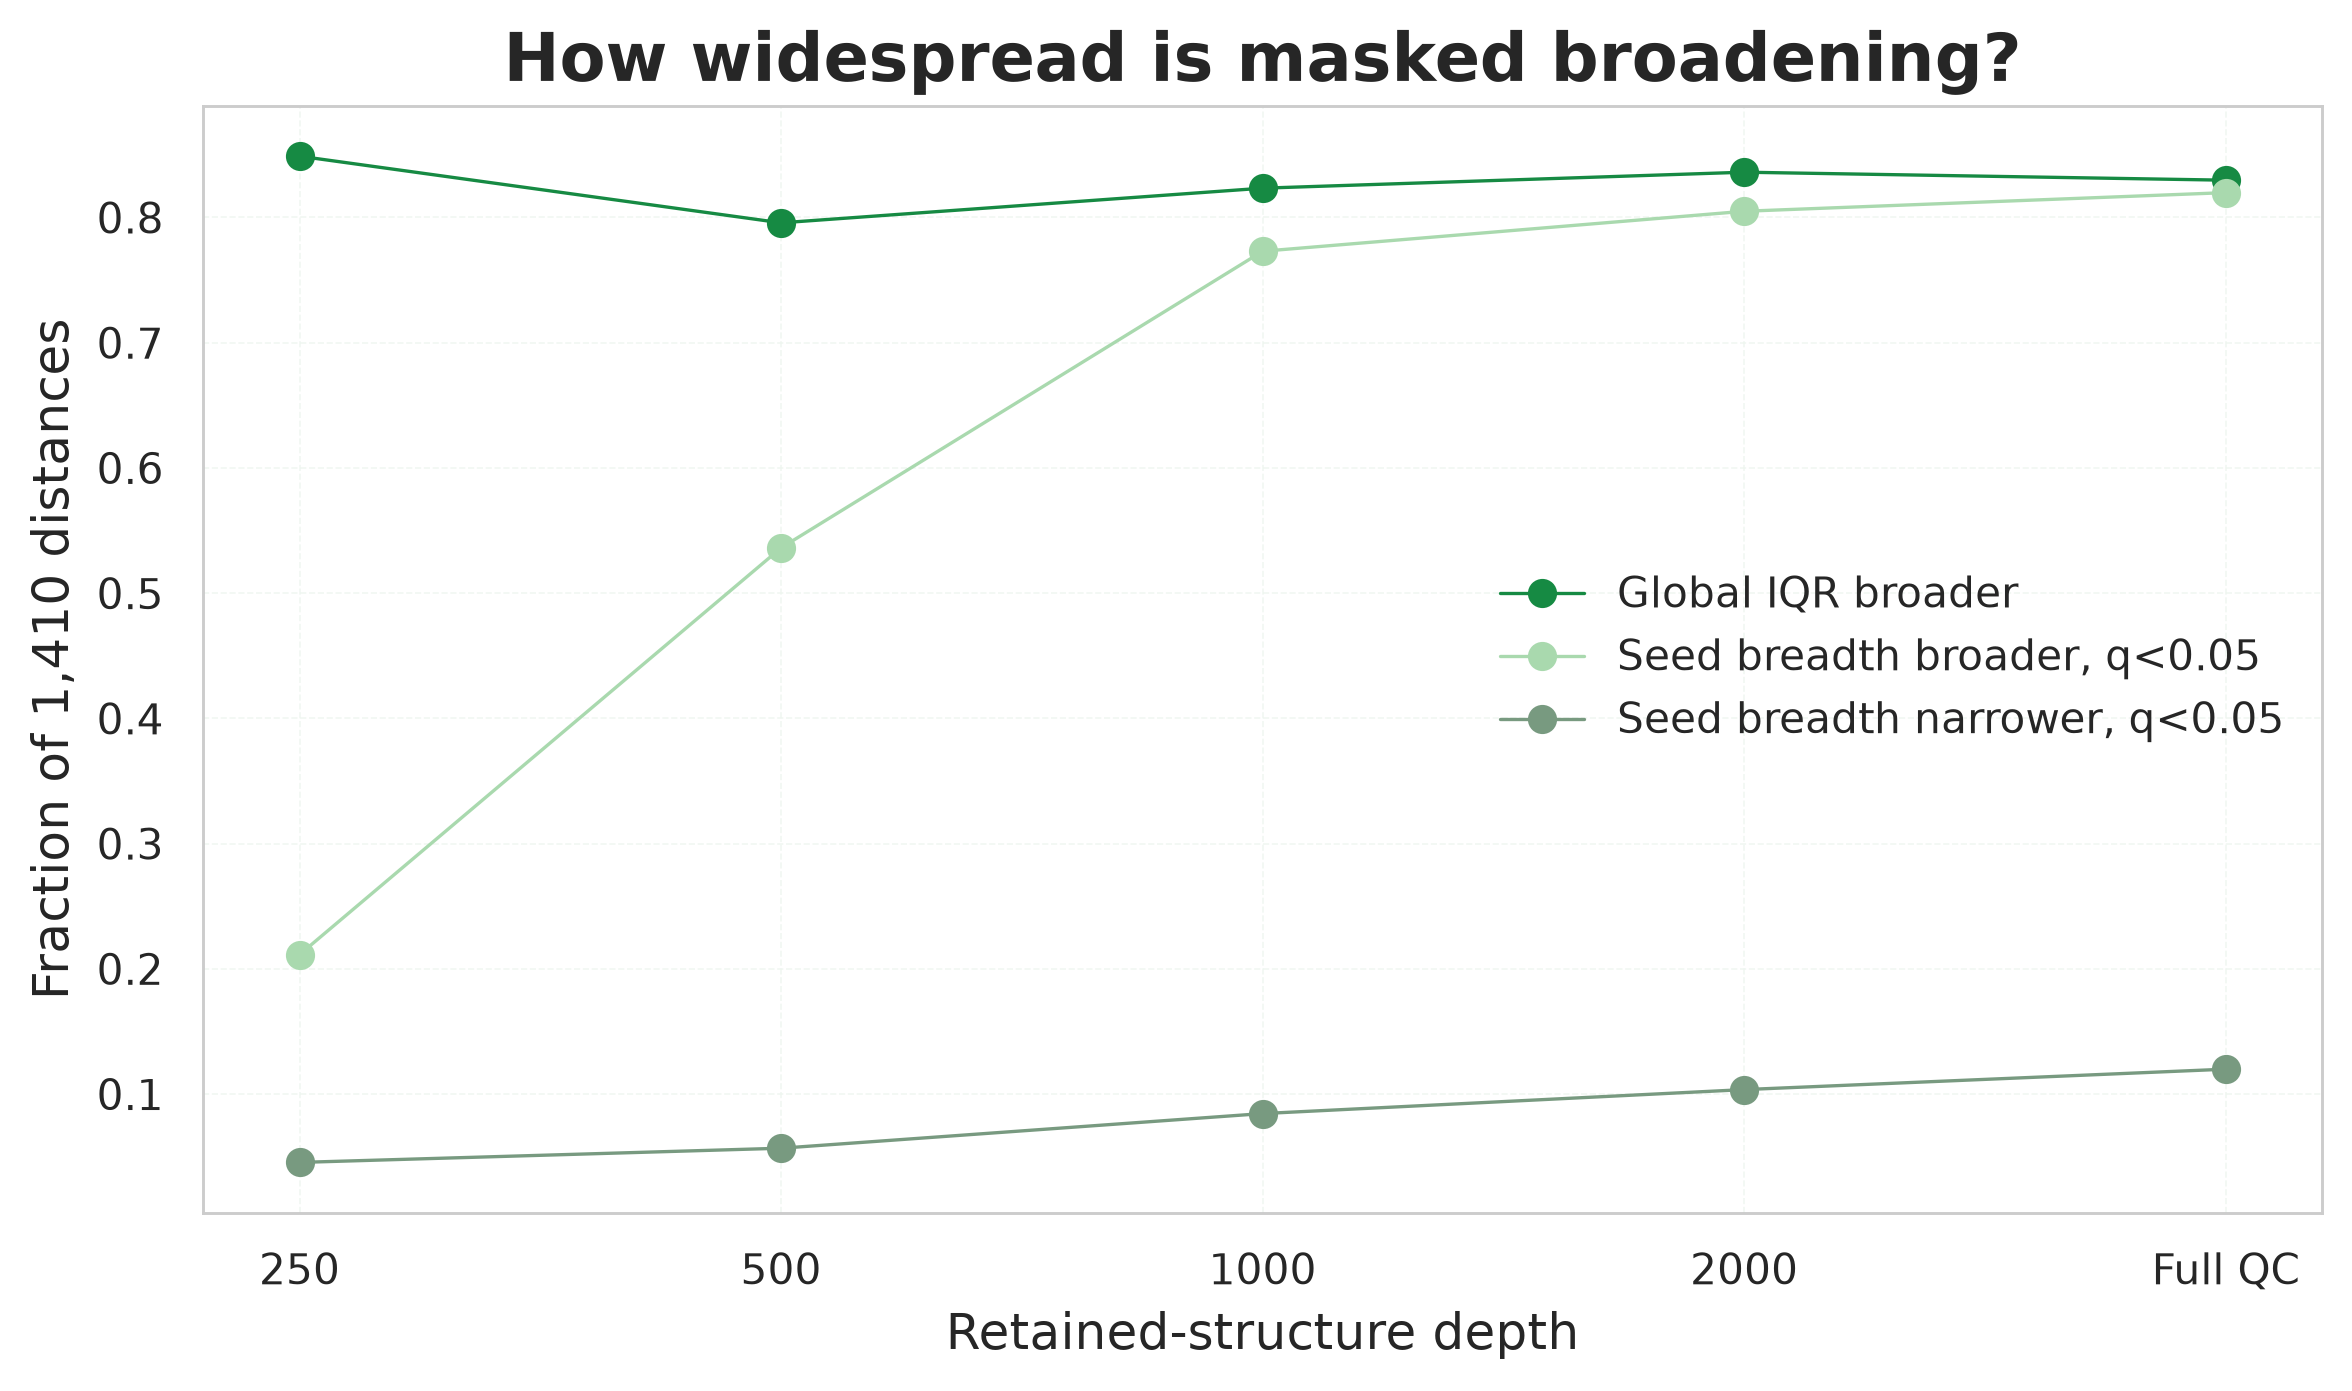

In [2]:
display(pd.read_csv(TAB/'l403a_all_distance_sampling_summary.csv')); display(Image(filename=str(FIG/'all_distance_breadth_fraction_by_depth.png')))

## First 1,000 versus full QC

,depth,metric,spearman_vs_full,p,same_direction_fraction
0,250,global_log2_IQR_ratio,0.531945,7.966169e-104,0.936879
1,250,seed_log2_IQR_ratio,0.608336,1.750162e-143,0.938298
2,250,trajectory_median_W1_A,0.971132,0.000000e+00,NaN
3,500,global_log2_IQR_ratio,0.204309,9.420268e-15,0.900000
4,500,seed_log2_IQR_ratio,0.760090,7.193078e-266,0.966667
5,500,trajectory_median_W1_A,0.991299,0.000000e+00,NaN
6,1000,global_log2_IQR_ratio,0.607125,9.076620e-143,0.950355
7,1000,seed_log2_IQR_ratio,0.985135,0.000000e+00,0.975177
8,1000,trajectory_median_W1_A,0.987227,0.000000e+00,NaN
9,2000,global_log2_IQR_ratio,0.989339,0.000000e+00,0.981560


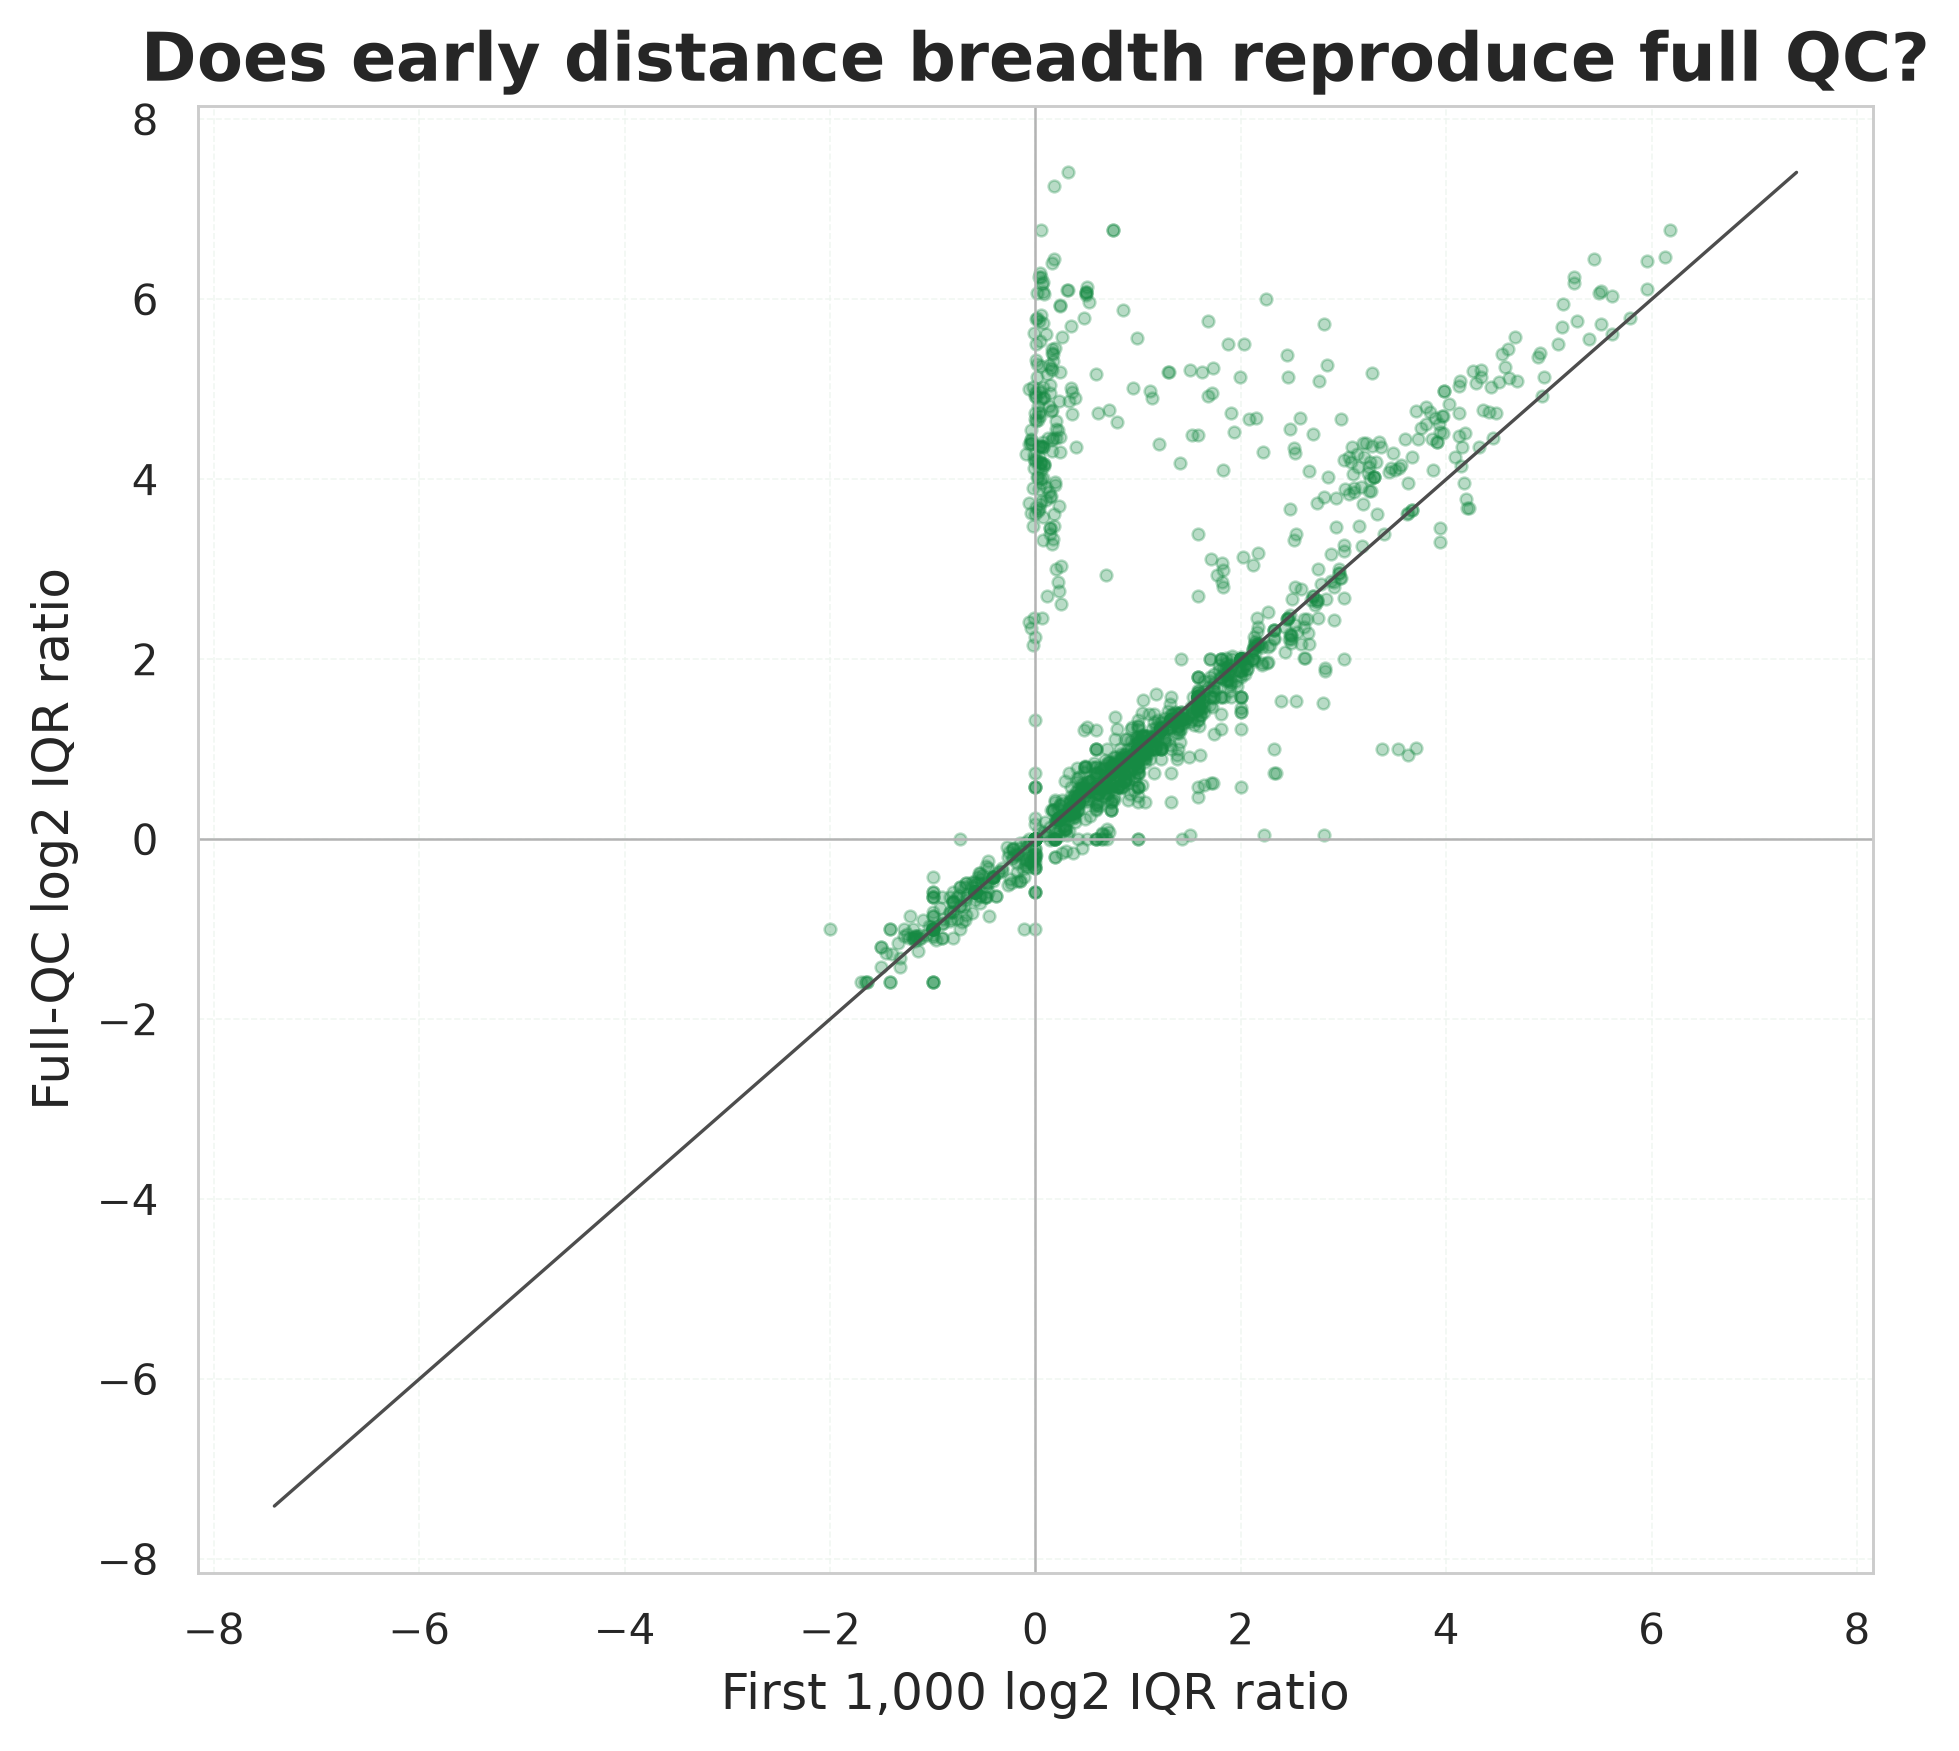

In [3]:
display(pd.read_csv(TAB/'l403a_all_distance_sampling_stability.csv')); display(Image(filename=str(FIG/'first1000_vs_full_distance_breadth.png')))

## Distribution of breadth effects across all 1,410 distances

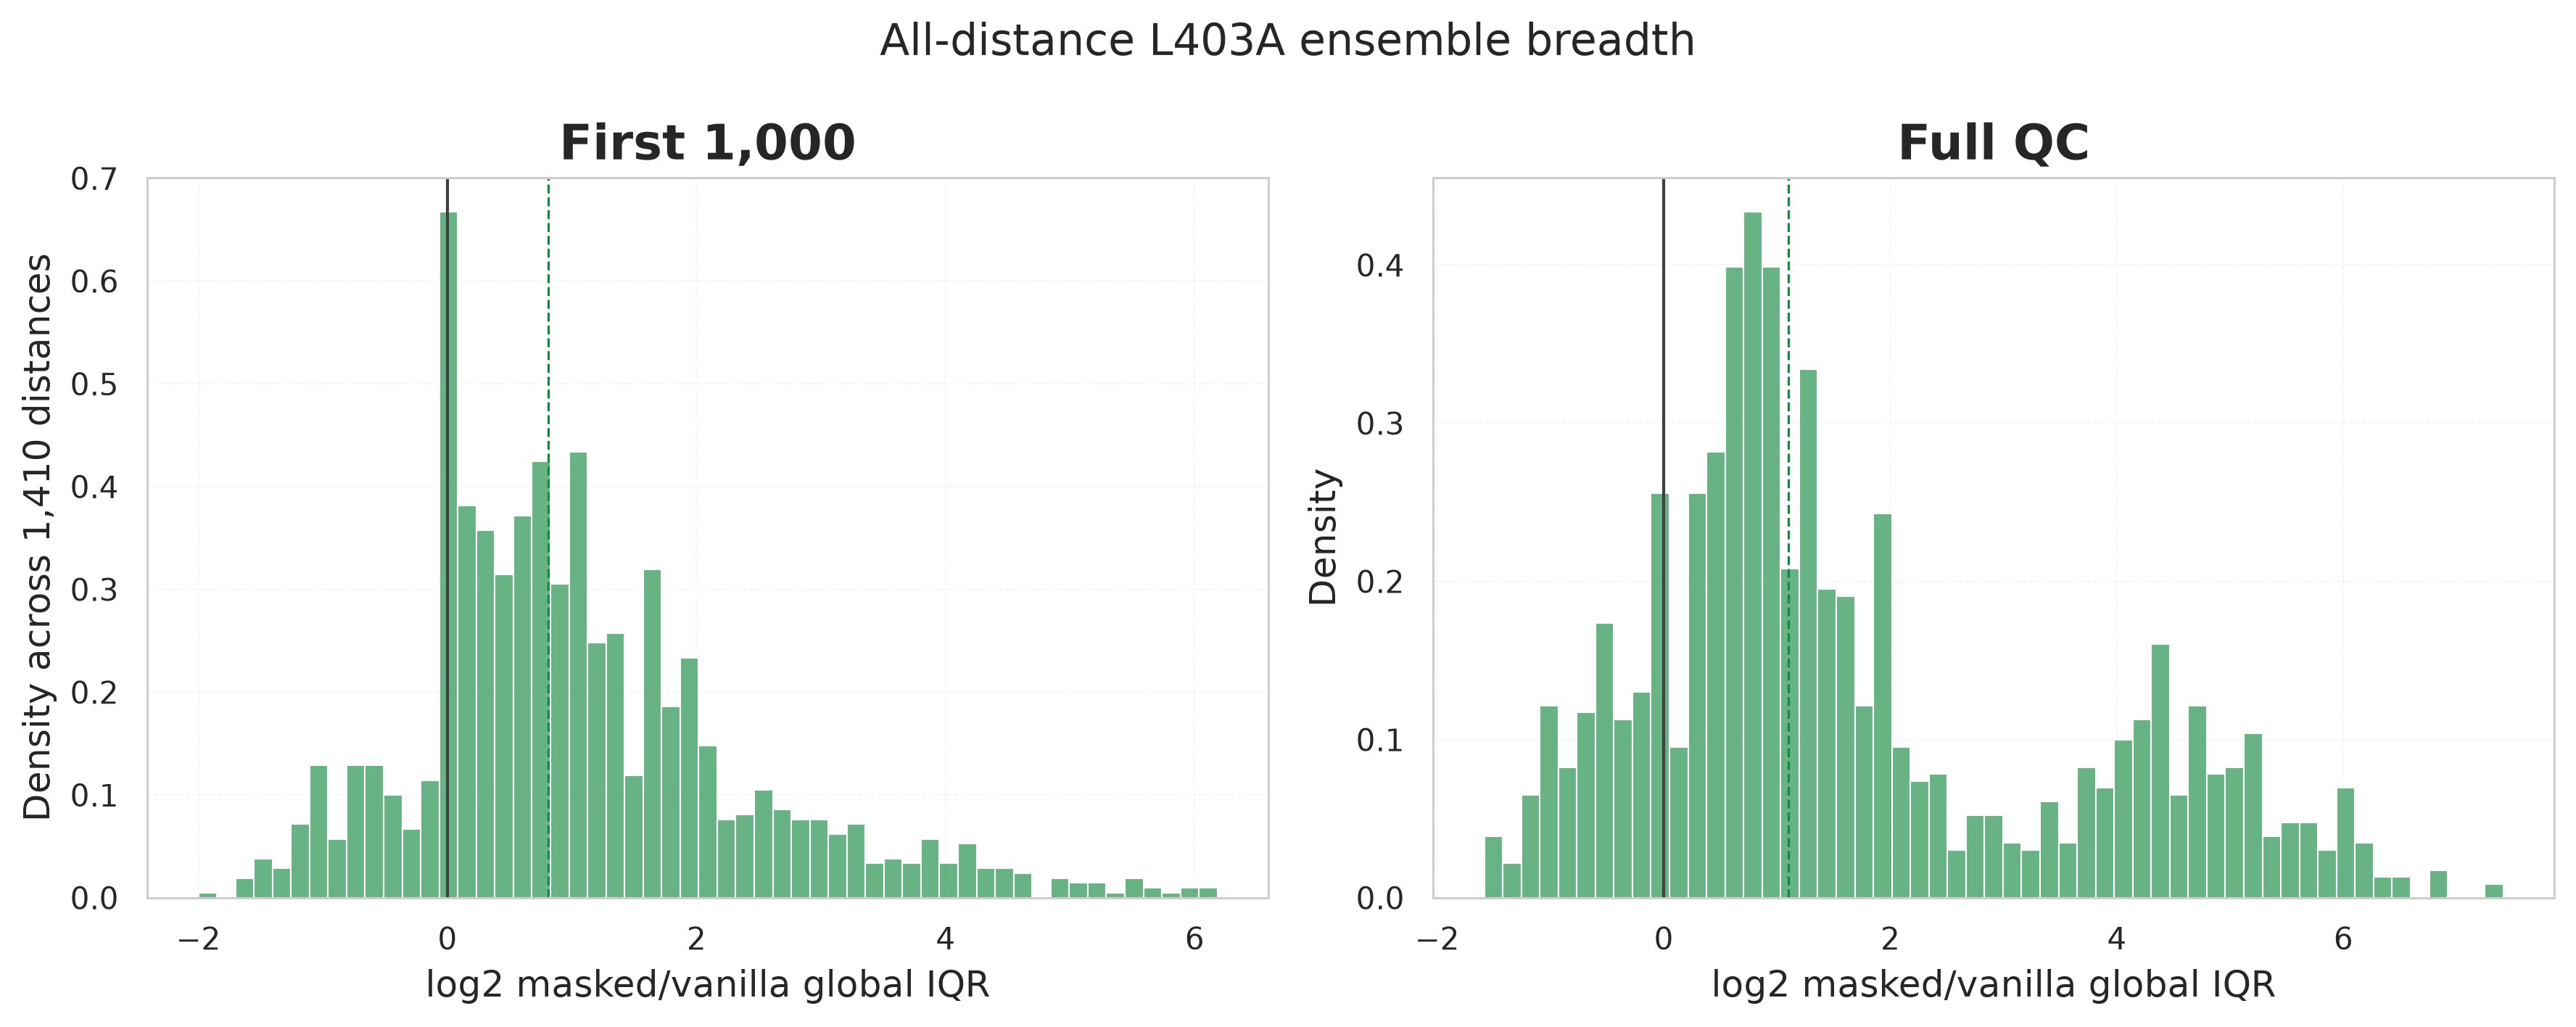

In [4]:
display(Image(filename=str(FIG/'all_distance_iqr_ratio_distributions.png')))

## Strongest concordant broadened and narrowed distances

,distance,global_log2_IQR_ratio_first1000,global_log2_IQR_ratio_full,concordant,min_abs
0,shortest_ALA405A-PHE414B,6.183222,6.768184,True,6.183222
1,CA_CA_A_ALA405_CA-B_PHE414_CA,6.134640,6.474880,True,6.134640
2,CA_CA_A_ALA405_CA-B_VAL411_CA,5.959475,6.421013,True,5.959475
3,CA_CA_A_ALA405_CA-B_LEU318_CA,5.957729,6.118200,True,5.957729
4,shortest_ALA405A-LEU318B,5.787903,5.787903,True,5.787903
5,shortest_VAL400A-ILE403B,5.614710,5.614710,True,5.614710
6,CA_CA_A_LEU315_CA-B_LEU331_CA,5.612137,6.038335,True,5.612137
7,CA_CA_A_ALA405_CA-B_TYR418_CA,5.505891,6.093391,True,5.505891
8,shortest_LEU315A-LEU331B,5.505528,5.723377,True,5.505528
9,shortest_ALA405A-VAL411B,5.491853,6.066089,True,5.491853


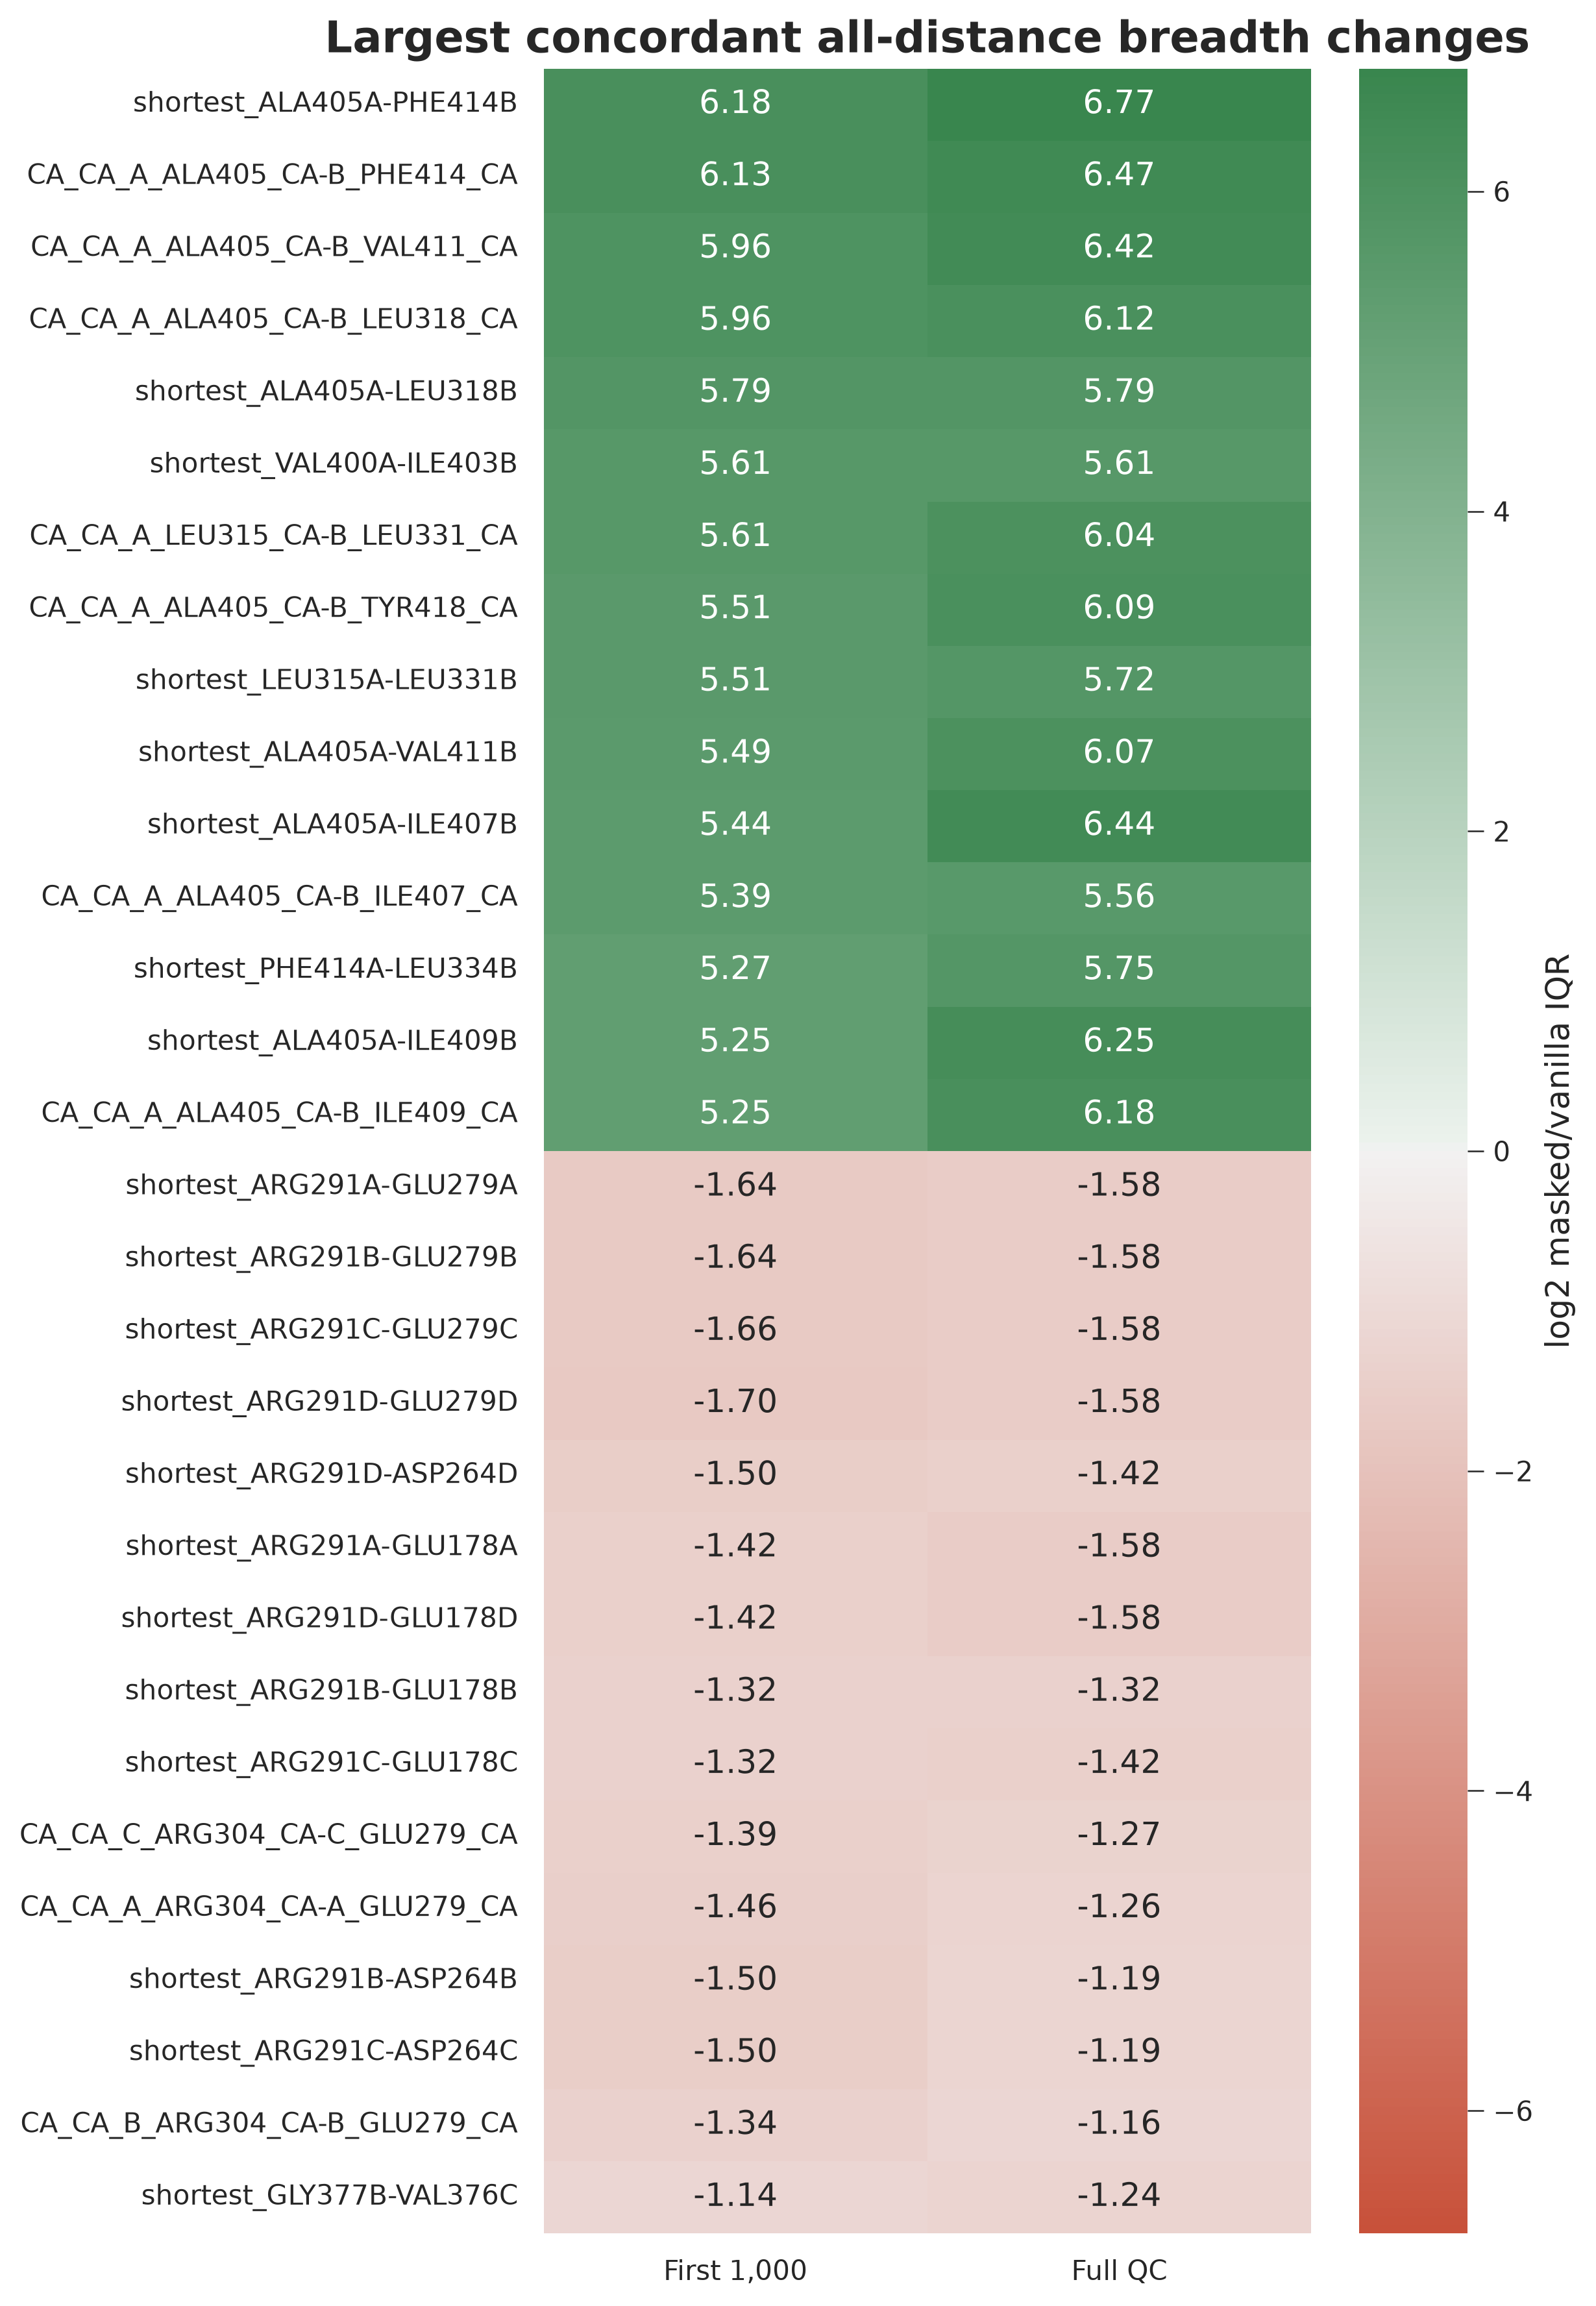

In [5]:
display(pd.read_csv(TAB/'top_concordant_distance_breadth_changes.csv')); display(Image(filename=str(FIG/'top_all_distance_breadth_heatmap.png')))

## Machine-readable distance-level statistics

In [6]:
stats=pd.read_csv(TAB/'l403a_all_distance_sampling_statistics.csv')
display(stats[stats.depth.astype(str).isin(['1000','Full QC'])])
print(f'{len(stats):,} distance-by-depth rows')

,depth,distance,distance_type,vanilla_median_A,masked_median_A,delta_median_A,vanilla_global_IQR_A,masked_global_IQR_A,global_IQR_ratio,global_log2_IQR_ratio,...,seed_breadth_p,seed_breadth_q,trajectory_median_W1_A,W1_normalized_pooled_IQR,vanilla_rows,masked_rows,vanilla_seeds,masked_seeds,vanilla_trajectories,masked_trajectories
2820,1000,CA_CA_A_ALA404_CA-B_ALA404_CA,CA,10.15,10.260,0.110,0.1600,0.30,1.875000,0.906891,...,9.664845e-09,5.766145e-08,0.288449,1.311132,1000,1000,23,28,109,117
2821,1000,CA_CA_A_ALA404_CA-B_ALA405_CA,CA,12.46,12.730,0.270,0.1700,0.31,1.823529,0.866733,...,9.885364e-07,2.768674e-06,0.462423,1.360068,1000,1000,23,28,109,117
2822,1000,CA_CA_A_ALA404_CA-B_ILE403_CA,CA,10.98,11.745,0.765,0.3000,1.69,5.633333,2.493989,...,1.473398e-04,2.777169e-04,0.942709,0.462112,1000,1000,23,28,109,117
2823,1000,CA_CA_A_ALA404_CA-B_ILE409_CA,CA,11.04,16.630,5.590,0.2425,5.93,24.453608,4.611975,...,5.502905e-04,9.298361e-04,2.038181,0.335227,1000,1000,23,28,109,117
2824,1000,CA_CA_A_ALA404_CA-B_PRO408_CA,CA,8.60,12.995,4.395,0.3300,4.84,14.666667,3.874469,...,1.022017e-03,1.627829e-03,1.673046,0.336460,1000,1000,23,28,109,117
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7045,Full QC,shortest_VAL411C-ILE403D,shortest_heavy,15.80,9.500,-6.300,0.5000,6.80,13.600000,3.765535,...,2.307815e-13,3.791603e-13,2.446061,0.365084,4371,3693,100,100,479,426
7046,Full QC,shortest_VAL411C-ILE409D,shortest_heavy,18.30,8.300,-10.000,0.6000,11.20,18.666667,4.222392,...,5.307055e-08,6.707660e-08,3.508747,0.310509,4371,3693,100,100,479,426
7047,Full QC,shortest_VAL411C-PRO408D,shortest_heavy,13.40,4.400,-9.000,0.6000,9.80,16.333333,4.029747,...,1.035442e-08,1.352414e-08,2.972023,0.309586,4371,3693,100,100,479,426
7048,Full QC,shortest_VAL411C-VAL400D,shortest_heavy,16.50,9.100,-7.400,0.3000,8.20,27.333333,4.772589,...,1.729132e-07,2.135629e-07,2.716168,0.331240,4371,3693,100,100,479,426


7,050 distance-by-depth rows


## Reading guide

- `global_IQR_ratio > 1` means the masked raw ensemble is broader for that distance.
- `seed_IQR_ratio > 1` means the typical within-seed masked ensemble is broader.
- `seed_breadth_q < 0.05` identifies FDR-significant protocol differences using seeds as replicates.
- `trajectory_median_W1_A` describes protocol separation after giving each seed/model trajectory one median observation.
- Agreement between first 1,000 and full QC supports sampling-efficiency claims; it does not convert deterministic seed order into chronological time.
- These all-distance results establish breadth, not whether broader states are experimentally correct.